# Exercise 19

### Classify digit 0-9 using KNN classifier. Figure out K that gives maximum score 
### Plot confusion matrix 
### Plot classification report

In [10]:
# import libraries 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# load dataset 
from sklearn.datasets import load_digits
digits = load_digits()

In [12]:
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [13]:
# define X and y 
X = digits.data 
y = digits.target

In [14]:
# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [15]:
# find best K using GridSearchCV
param_grid = {'n_neighbors': range(1, 11)}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best K:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best K: {'n_neighbors': 3}
Best Score: 0.9888671118854045


In [16]:
# train with best K
knn = grid.best_estimator_
y_pred = knn.predict(X_test)

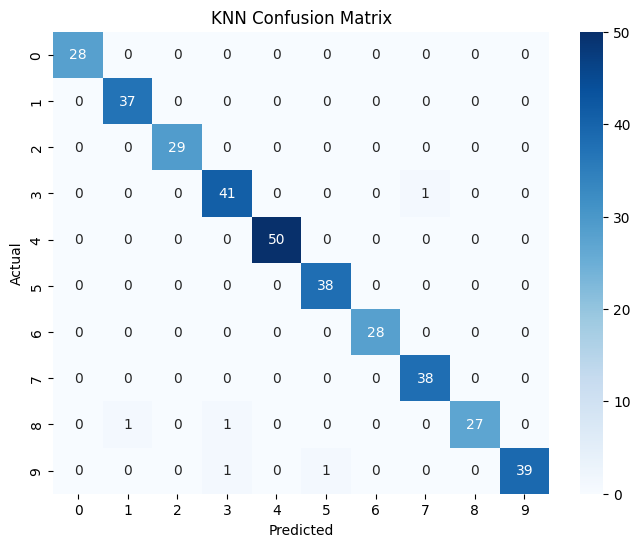

In [17]:
# plot confusion matrix 
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()


In [18]:
# plot classification report 
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       0.97      1.00      0.99        37
           2       1.00      1.00      1.00        29
           3       0.95      0.98      0.96        42
           4       1.00      1.00      1.00        50
           5       0.97      1.00      0.99        38
           6       1.00      1.00      1.00        28
           7       0.97      1.00      0.99        38
           8       1.00      0.93      0.96        29
           9       1.00      0.95      0.97        41

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360

